# Ising Model Simulation
## Two-dimensional Ising model using the Metropolis algorithm
Based on original code by Dan Schroeder, Weber State University, January 2013

Adapted for Jupyter notebooks using matplotlib and ipywidgets

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display
import ipywidgets as widgets
import random
import math

%matplotlib widget


In [2]:
# Simulation parameters
size = 50                                      # number of sites in a lattice row
s = np.ones((size, size), dtype=int)          # 2D array of dipoles (1=up, -1=down)
running = False                                # simulation state
temperature = 2.27                             # initial temperature (critical temperature)

# Initialize to a random array
for i in range(size):
    for j in range(size):
        s[i,j] = 1 if random.random() < 0.5 else -1

print(f"Initialized {size}x{size} lattice with random spins")


Initialized 50x50 lattice with random spins


In [3]:
# Function to calculate energy change upon hypothetical flip (with periodic boundary conditions)
def deltaE(i, j):
    """Calculate the energy change if spin at (i,j) is flipped"""
    leftS = s[size-1, j] if i == 0 else s[i-1, j]
    rightS = s[0, j] if i == size-1 else s[i+1, j]
    topS = s[i, size-1] if j == 0 else s[i, j-1]
    bottomS = s[i, 0] if j == size-1 else s[i, j+1]
    return 2.0 * s[i, j] * (leftS + rightS + topS + bottomS)


In [4]:
# Animation update function
def update(frame):
    global s, running, temperature
    
    if running:
        # Perform multiple Monte Carlo steps per frame for smoother simulation
        for step in range(1000):
            i = random.randint(0, size-1)
            j = random.randint(0, size-1)
            eDiff = deltaE(i, j)
            
            # Metropolis algorithm: accept flip if it lowers energy
            # or with probability exp(-ΔE/T) if it raises energy
            if eDiff <= 0 or random.random() < math.exp(-eDiff/temperature):
                s[i, j] = -s[i, j]
        
        # Update the display
        im.set_array(s)
        ax.set_title(f'Ising Model (T = {temperature:.2f})')
    
    return [im]



Instructions:
- Click 'Start' to begin the simulation
- Adjust the temperature slider to see phase transitions
- T ≈ 2.27 is the critical temperature for the 2D Ising model
- Below Tc: ordered phase (mostly purple or white)
- Above Tc: disordered phase (mixed purple and white)


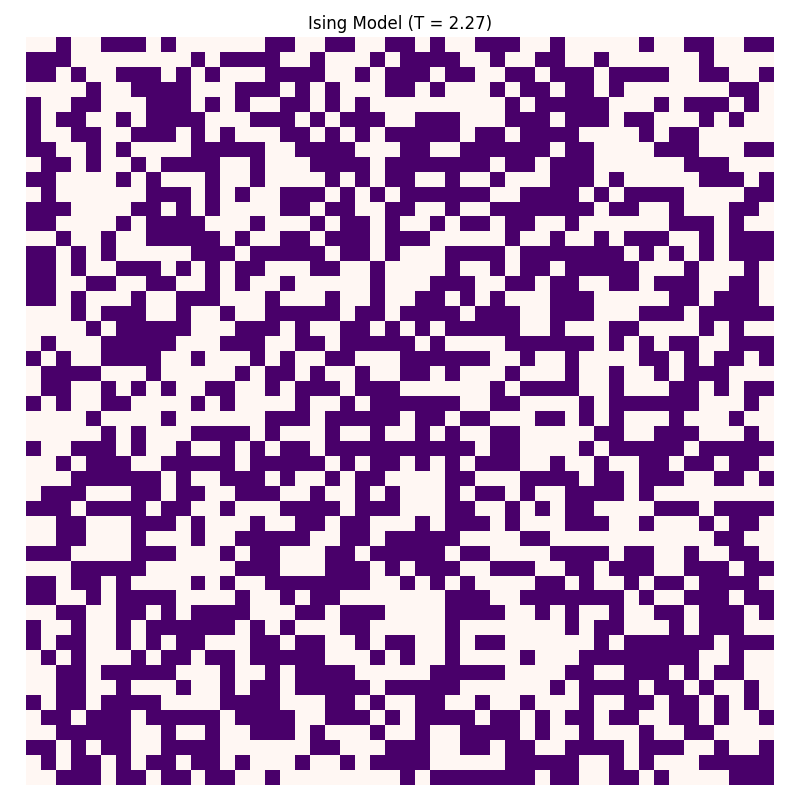

In [5]:
# Create interactive widgets
start_button = widgets.Button(
    description='Start',
    button_style='success',
    layout=widgets.Layout(width='100px')
)

temp_slider = widgets.FloatSlider(
    value=2.27,
    min=0.01,
    max=10.0,
    step=0.01,
    description='Temperature:',
    continuous_update=True,
    layout=widgets.Layout(width='400px')
)

# Button click handler
def on_button_click(b):
    global running
    running = not running
    if running:
        start_button.description = 'Pause'
        start_button.button_style = 'warning'
    else:
        start_button.description = 'Resume'
        start_button.button_style = 'success'

# Temperature slider handler
def on_temp_change(change):
    global temperature
    temperature = change['new']

start_button.on_click(on_button_click)
temp_slider.observe(on_temp_change, names='value')

# Display widgets
controls = widgets.HBox([temp_slider, start_button])
display(controls)

print("\nInstructions:")
print("- Click 'Start' to begin the simulation")
print("- Adjust the temperature slider to see phase transitions")
print("- T ≈ 2.27 is the critical temperature for the 2D Ising model")
print("- Below Tc: ordered phase (mostly purple or white)")
print("- Above Tc: disordered phase (mixed purple and white)")


# Create animation
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(s, cmap='RdPu', vmin=-1, vmax=1, interpolation='nearest')
ax.set_title(f'Ising Model (T = {temperature:.2f})')
ax.axis('off')
plt.tight_layout()
anim = FuncAnimation(fig, update, interval=1, blit=True, cache_frame_data=False)
